In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import locale
import os

DATA_DIR = Path('/workspace/data/')
FIGURE_DIR = Path('/workspace/figures/xv')

FIGURE_DIR.mkdir(exist_ok=True)

In [2]:
df = pd.read_pickle(DATA_DIR/"df_final.pkl")
df

target,10.254.211.203,100.80.21.72,192,192.168.1.2,192.168.1.254,1banda.com,3dcuritiba.com.br,3dlab.com.br,3m.com.br,3pitech.com,...,ynab.com,youtube.com,ytdlp,z2jh.jupyter.org,zepp.com,zobnin.github.io,zorin.com,zotero.org,zotfile.com,∞ ENERGY
2025-02-18,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-02-19,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-02-20,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-02-21,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-02-22,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-10-25,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-10-26,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-10-27,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
xv = df[[ col for col in df.columns if "xv" in col ]].sum(axis=1)
xv = xv / 60

xv = xv.to_frame(name="minutes")
xv.index.name = 'day'
xv

,minutes
day,
2025-02-18,0.000000
2025-02-19,0.500000
2025-02-20,0.000000
2025-02-21,0.000000
2025-02-22,0.000000
...,...
2025-10-24,7.533333
2025-10-25,0.000000
2025-10-26,5.333333


Gerando e salvando gráfico com a visão geral de todo o período...
Gráfico geral salvo em: /workspace/figures/xv/2025_analise.png


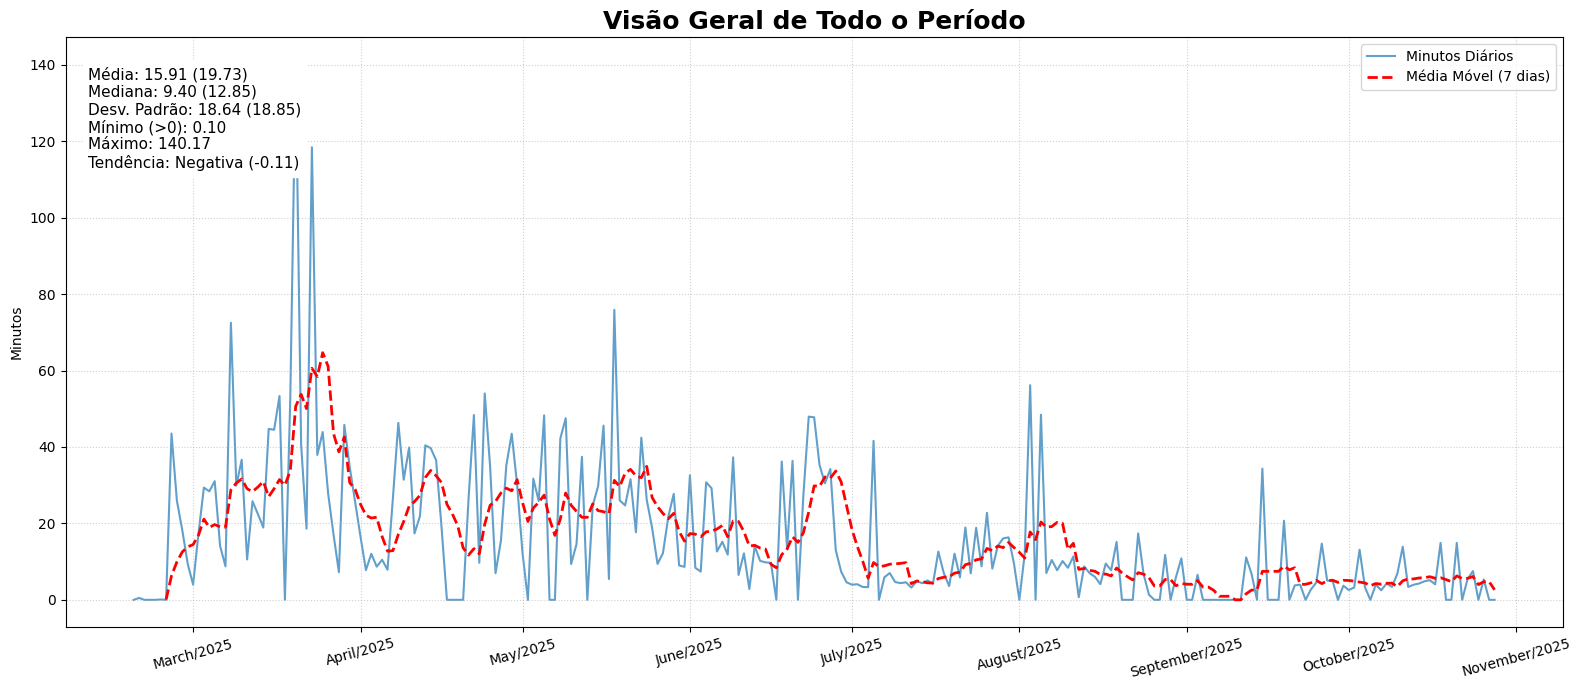


Gerando e salvando gráficos individuais para cada mês...
Gráfico mensal salvo em: /workspace/figures/xv/2025-02_analise.png


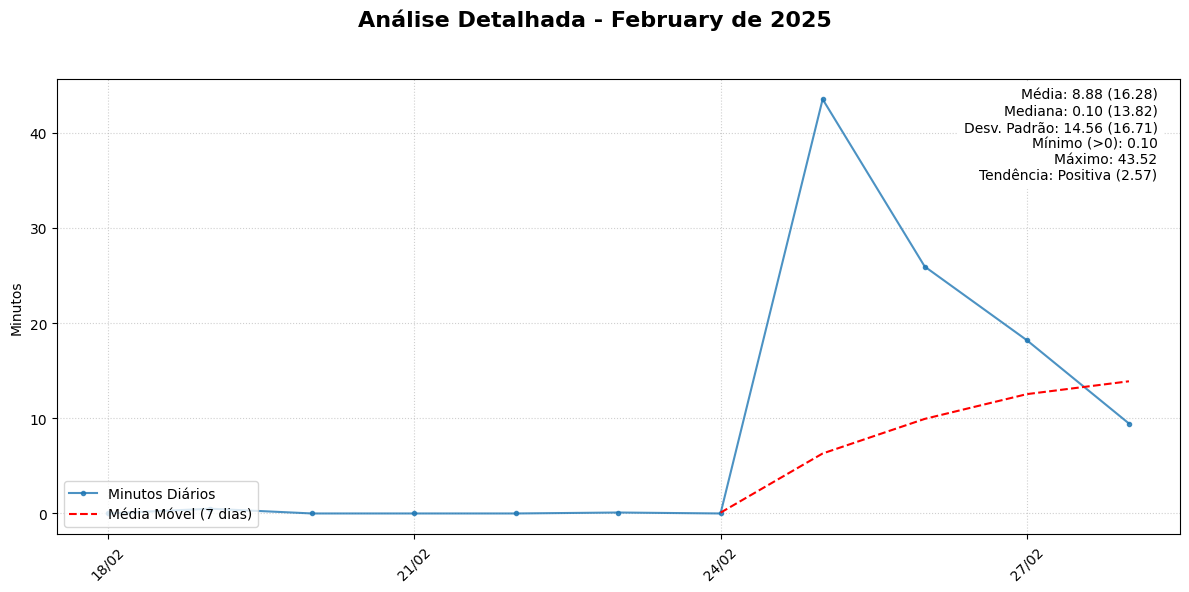

Gráfico mensal salvo em: /workspace/figures/xv/2025-03_analise.png


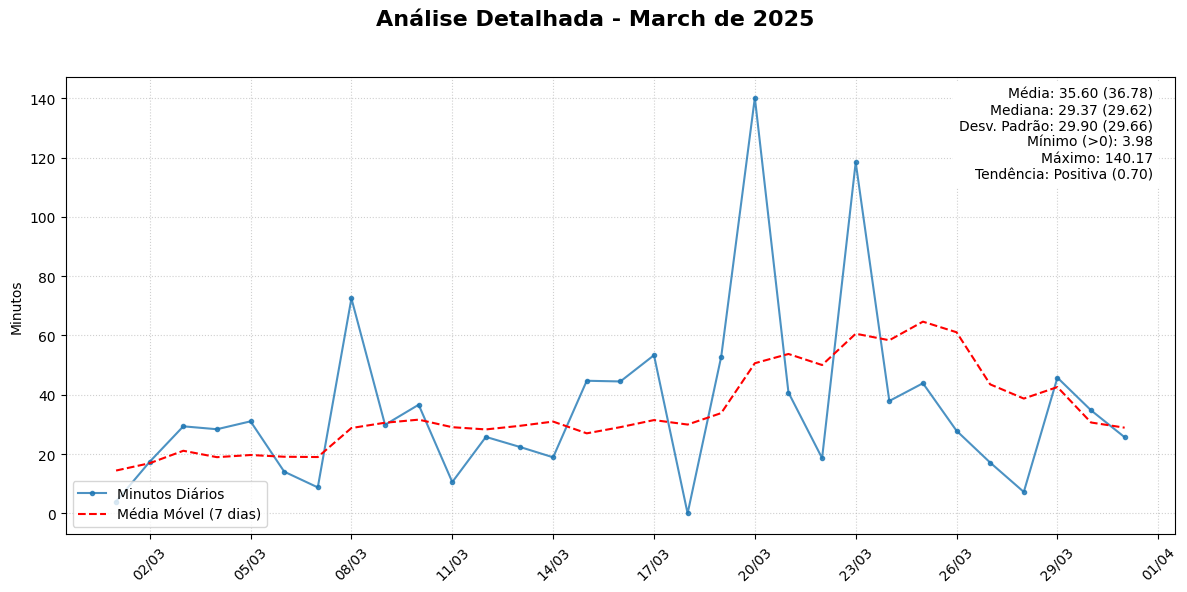

Gráfico mensal salvo em: /workspace/figures/xv/2025-04_analise.png


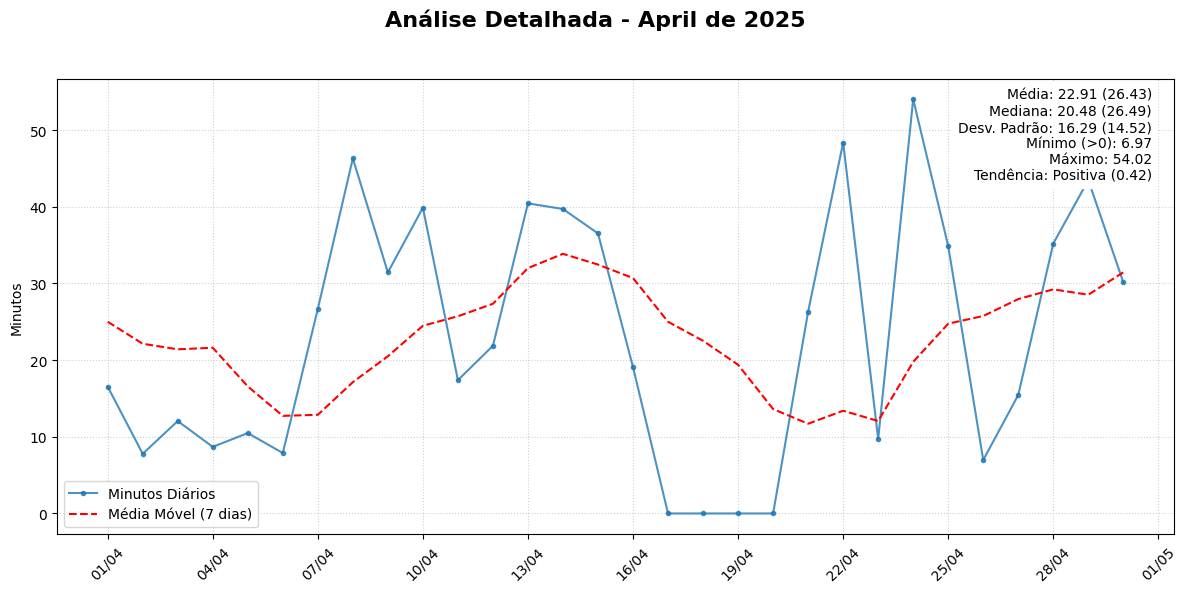

Gráfico mensal salvo em: /workspace/figures/xv/2025-05_analise.png


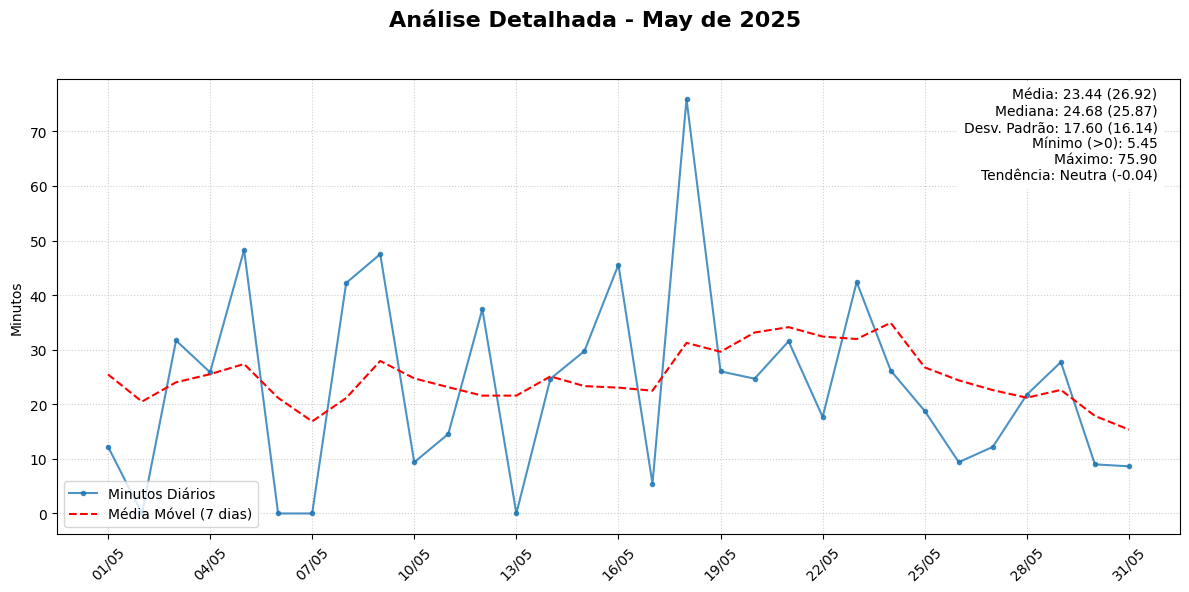

Gráfico mensal salvo em: /workspace/figures/xv/2025-06_analise.png


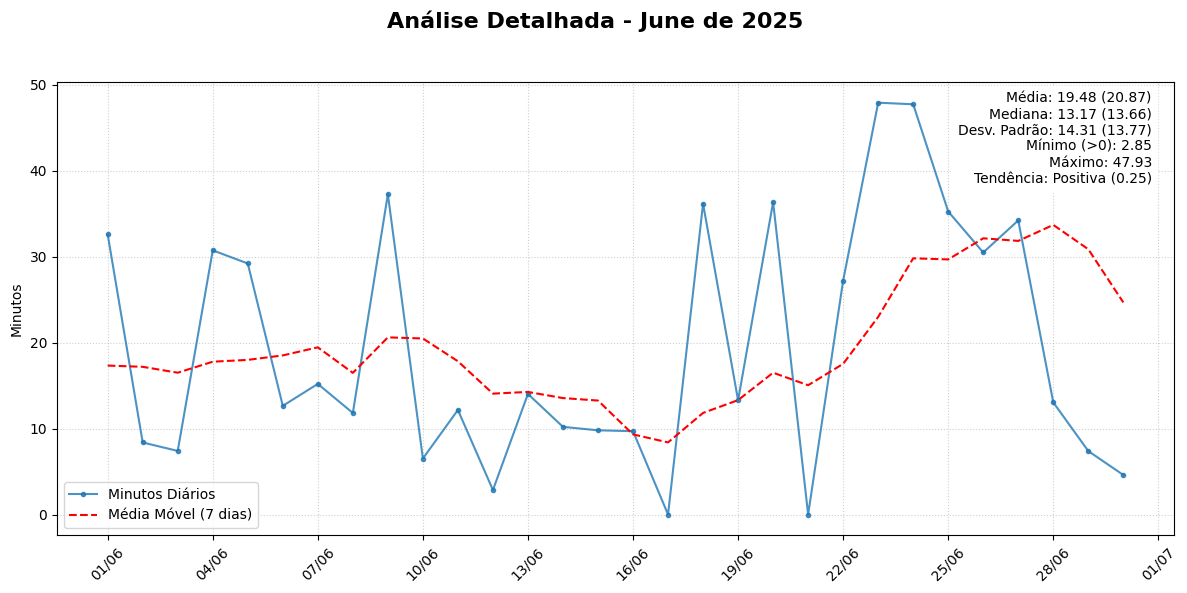

Gráfico mensal salvo em: /workspace/figures/xv/2025-07_analise.png


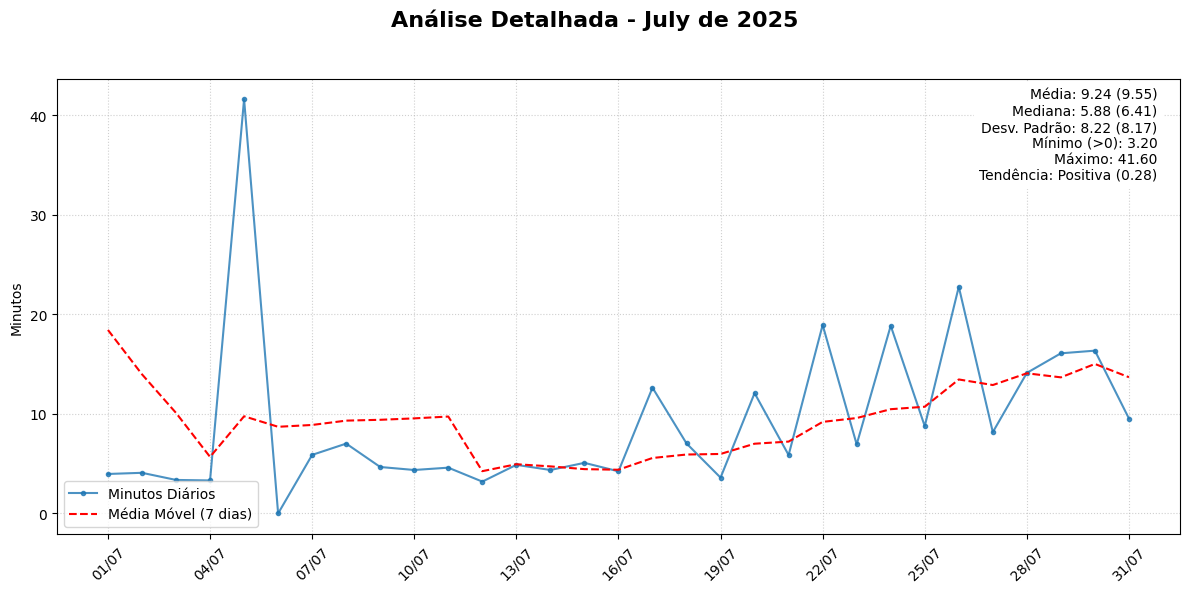

Gráfico mensal salvo em: /workspace/figures/xv/2025-08_analise.png


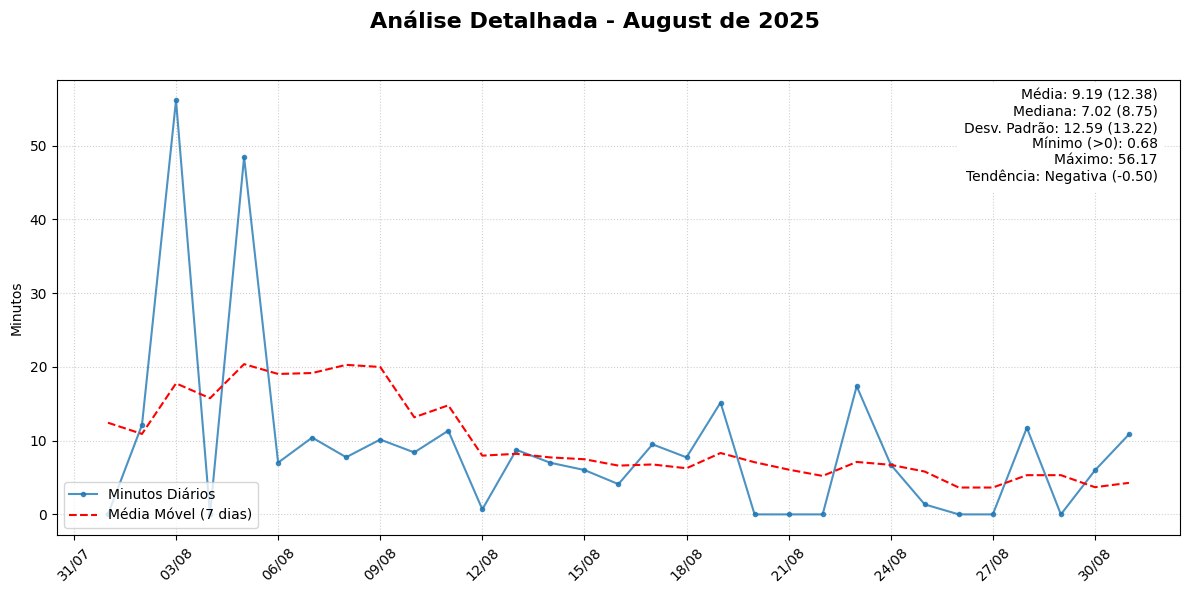

Gráfico mensal salvo em: /workspace/figures/xv/2025-09_analise.png


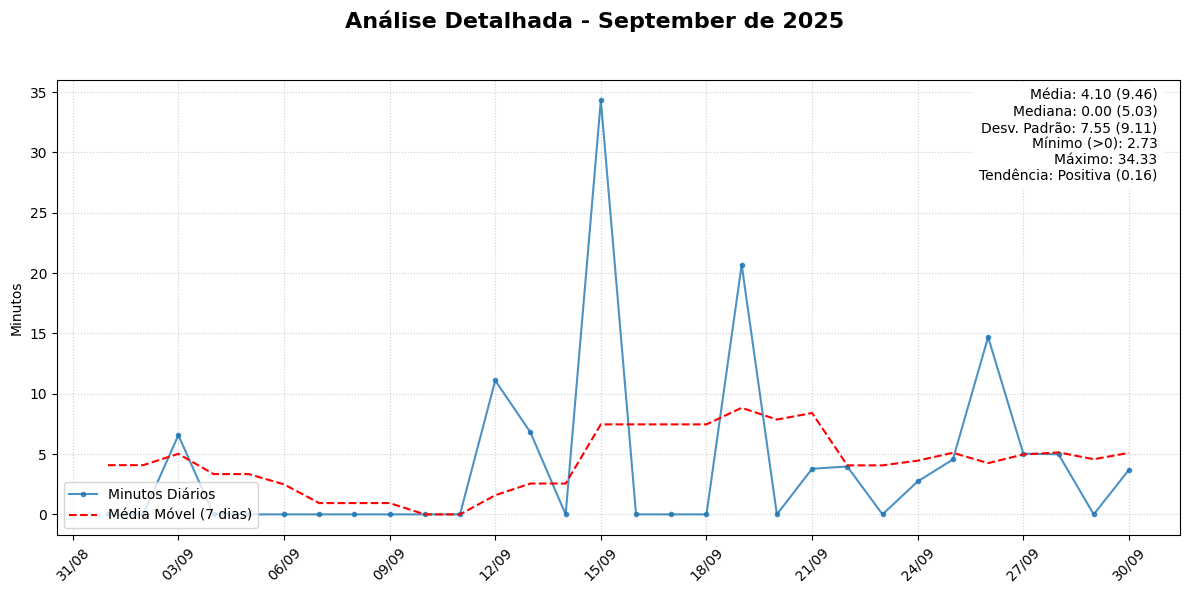

Gráfico mensal salvo em: /workspace/figures/xv/2025-10_analise.png


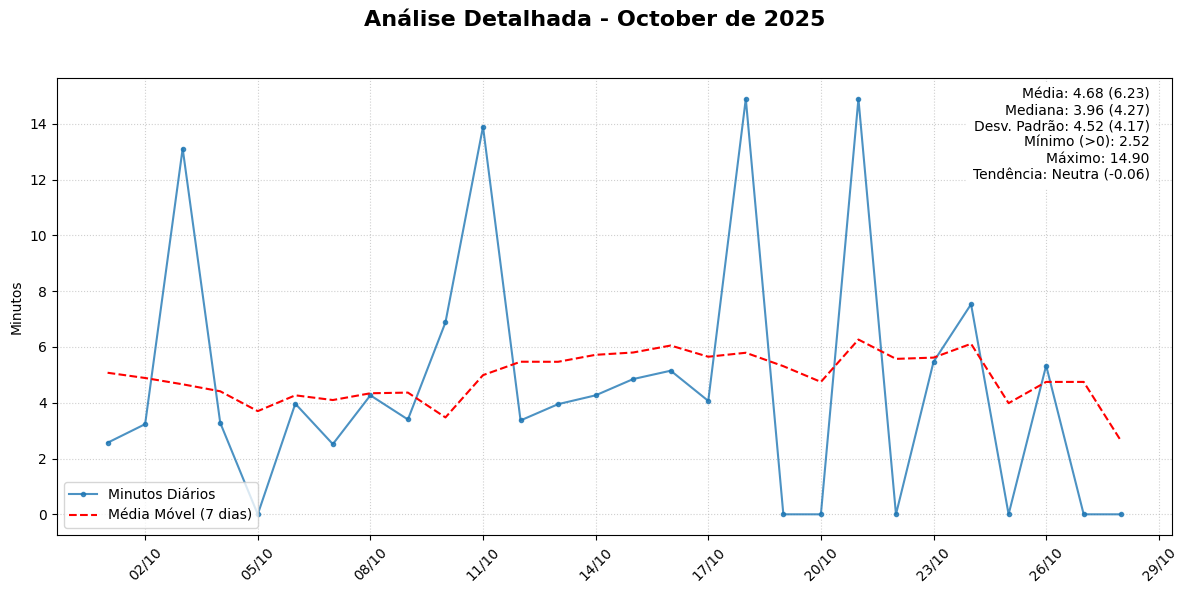


Processo concluído!


In [6]:
def gerar_texto_estatisticas(df):
    """
    Calcula estatísticas de um DataFrame, com e sem valores zero,
    e retorna um texto formatado.
    """
    minutos_validos = df['minutes'].dropna()

    if minutos_validos.empty:
        return "Dados insuficientes"

    # Cálculos com todos os dados
    media_com_zero = minutos_validos.mean()
    mediana_com_zero = minutos_validos.median()
    desvio_pad_com_zero = minutos_validos.std()
    maximo = minutos_validos.max()

    # Cálculos desconsiderando os valores zero
    minutos_sem_zero = minutos_validos[minutos_validos > 0]
    if not minutos_sem_zero.empty:
        media_sem_zero = minutos_sem_zero.mean()
        mediana_sem_zero = minutos_sem_zero.median()
        desvio_pad_sem_zero = minutos_sem_zero.std()
        minimo = minutos_sem_zero.min()
    else:
        media_sem_zero, mediana_sem_zero, desvio_pad_sem_zero, minimo = 0, 0, 0, 0

    # Cálculo da tendência
    if len(minutos_validos) > 1:
        x_numeric = np.arange(len(minutos_validos))
        slope, _ = np.polyfit(x_numeric, minutos_validos.values, 1)
        if slope > 0.1:
            tendencia_desc = f"Positiva ({slope:.2f})"
        elif slope < -0.1:
            tendencia_desc = f"Negativa ({slope:.2f})"
        else:
            tendencia_desc = f"Neutra ({slope:.2f})"
    else:
        tendencia_desc = "N/A"

    # Formatação do texto final
    texto = (
        f"Média: {media_com_zero:.2f} ({media_sem_zero:.2f})\n"
        f"Mediana: {mediana_com_zero:.2f} ({mediana_sem_zero:.2f})\n"
        f"Desv. Padrão: {desvio_pad_com_zero:.2f} ({desvio_pad_sem_zero:.2f})\n"
        f"Mínimo (>0): {minimo:.2f}\n"
        f"Máximo: {maximo:.2f}\n"
        f"Tendência: {tendencia_desc}"
    )
    return texto


xv['mean'] = xv['minutes'].rolling(window=7).mean()

print("Gerando e salvando gráfico com a visão geral de todo o período...")

fig_total = plt.figure(figsize=(16, 7)) # Pega a referência da figura
ax_total = plt.gca()

ax_total.plot(xv.index, xv['minutes'], label='Minutos Diários', alpha=0.7, zorder=1)
ax_total.plot(xv.index, xv['mean'], label='Média Móvel (7 dias)', color='red', linestyle='--', linewidth=2, zorder=2)
ax_total.xaxis.set_major_locator(mdates.MonthLocator())
ax_total.xaxis.set_major_formatter(mdates.DateFormatter('%B/%Y'))
ax_total.tick_params(axis='x', rotation=15)
ax_total.set_title('Visão Geral de Todo o Período', fontsize=18, weight='bold')
ax_total.set_ylabel('Minutos')
ax_total.legend()
ax_total.grid(True, linestyle=':', alpha=0.6)

texto_stats_total = gerar_texto_estatisticas(xv)
ax_total.text(0.015, 0.95, texto_stats_total, transform=ax_total.transAxes, fontsize=11,
              verticalalignment='top', backgroundcolor='w')

plt.tight_layout()


caminho_arquivo_total = FIGURE_DIR / f"2025_analise.png"

plt.savefig(caminho_arquivo_total, dpi=150) 
print(f"Gráfico geral salvo em: {caminho_arquivo_total}")

plt.show()
plt.close(fig_total) # Fecha a figura para liberar memória

grupos_mensais = xv.groupby(pd.Grouper(freq='ME'))

print("\nGerando e salvando gráficos individuais para cada mês...")

for mes_timestamp, df_mes in grupos_mensais:
    if df_mes.empty:
        continue

    fig, ax_mes = plt.subplots(figsize=(12, 6))

    nome_mes_ano = mes_timestamp.strftime('%B de %Y').capitalize()
    fig.suptitle(f"Análise Detalhada - {nome_mes_ano}", fontsize=16, weight='bold')

    ax_mes.plot(df_mes.index, df_mes['minutes'], label='Minutos Diários', marker='.', linestyle='-', alpha=0.8)
    ax_mes.plot(df_mes.index, df_mes['mean'], label='Média Móvel (7 dias)', color='red', linestyle='--')
    ax_mes.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax_mes.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    ax_mes.tick_params(axis='x', rotation=45)
    ax_mes.set_ylabel('Minutos')
    ax_mes.legend(loc='lower left')
    ax_mes.grid(True, linestyle=':', alpha=0.6)

    texto_stats_mes = gerar_texto_estatisticas(df_mes)
    ax_mes.text(0.98, 0.98, texto_stats_mes, transform=ax_mes.transAxes, fontsize=10,
                verticalalignment='top', horizontalalignment='right', backgroundcolor='w')

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    ### ALTERAÇÃO ###
    # Criar um nome de arquivo padronizado para fácil ordenação (ex: 2024-01_analise.png)
    nome_arquivo = f"{mes_timestamp.strftime('%Y-%m')}_analise.png"
    caminho_arquivo_mes = FIGURE_DIR / nome_arquivo
    plt.savefig(caminho_arquivo_mes, dpi=150)
    print(f"Gráfico mensal salvo em: {caminho_arquivo_mes}")

    plt.show()
    plt.close(fig) # Fecha a figura atual do loop para liberar memória

print("\nProcesso concluído!")

In [5]:
raise

RuntimeError: No active exception to reraise

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import locale

# --- PASSO 0: Função Auxiliar para Estatísticas ---

def gerar_texto_estatisticas(df):
    """
    Calcula estatísticas de um DataFrame e retorna um texto formatado.
    """
    # Garante que a coluna 'minutes' não tenha valores nulos para os cálculos
    minutos_validos = df['minutes'].dropna()

    if minutos_validos.empty:
        return "Dados insuficientes"

    # 1. Cálculos estatísticos básicos
    media = minutos_validos.mean()
    mediana = minutos_validos.median()
    desvio_pad = minutos_validos.std()
    minimo = minutos_validos.min()
    maximo = minutos_validos.max()

    # 2. Cálculo da tendência (usando regressão linear simples)
    # Precisamos de pelo menos 2 pontos para calcular uma tendência
    if len(minutos_validos) > 1:
        # np.polyfit precisa de um eixo X numérico (0, 1, 2, ...)
        x_numeric = np.arange(len(minutos_validos))
        # Ajusta uma linha (polinômio de grau 1) aos dados
        slope, _ = np.polyfit(x_numeric, minutos_validos.values, 1)

        # Classifica a tendência com base na inclinação (slope) da linha
        if slope > 0.1: # Limiar para considerar a tendência
            tendencia_desc = f"Positiva ({slope:.2f})"
        elif slope < -0.1:
            tendencia_desc = f"Negativa ({slope:.2f})"
        else:
            tendencia_desc = f"Neutra ({slope:.2f})"
    else:
        tendencia_desc = "N/A"

    # 3. Formatação do texto final
    texto = (
        f"Estatísticas:\n"
        f" Média: {media:.2f}\n"
        f" Mediana: {mediana:.2f}\n"
        f" Desv. Padrão: {desvio_pad:.2f}\n"
        f" Mínimo: {minimo:.0f}\n"
        f" Máximo: {maximo:.0f}\n"
        f" Tendência: {tendencia_desc}"
    )
    return texto


# --- PASSO 1: Preparar os dados ---

# Definir o locale para português
try:
    locale.setlocale(locale.LC_TIME, 'pt_BR.UTF-8')
except locale.Error:
    print("Locale pt_BR não encontrado, usando o padrão do sistema.")

# Criar um DataFrame de exemplo chamado 'xv' (DESCOMENTE PARA TESTAR)
# (Esta parte pode ser substituída pela sua fonte de dados real)
# datas = pd.date_range(start='2024-01-01', end='2024-04-30', freq='D')
# dados = {
    # 'minutes': np.random.randint(30, 120, size=len(datas)) + np.sin(np.arange(len(datas)) / 30) * 25 + 10
# }
# xv = pd.DataFrame(dados, index=datas)

# Calcular a média móvel de 7 dias
xv['mean'] = xv['minutes'].rolling(window=7).mean()


# --- PASSO 2: Plotar o gráfico com todos os dados ---

print("Exibindo gráfico com a visão geral de todo o período...")
plt.figure(figsize=(16, 7))
ax_total = plt.gca()

ax_total.plot(xv.index, xv['minutes'], label='Minutos Diários', alpha=0.7, zorder=1)
ax_total.plot(xv.index, xv['mean'], label='Média Móvel (7 dias)', color='red', linestyle='--', linewidth=2, zorder=2)

ax_total.xaxis.set_major_locator(mdates.MonthLocator())
ax_total.xaxis.set_major_formatter(mdates.DateFormatter('%B/%Y'))
ax_total.tick_params(axis='x', rotation=15)

ax_total.set_title('Visão Geral de Todo o Período', fontsize=18, weight='bold')
ax_total.set_ylabel('Minutos')
ax_total.legend()
ax_total.grid(True, linestyle=':', alpha=0.6)

# Adicionar a caixa de texto com estatísticas
texto_stats_total = gerar_texto_estatisticas(xv)
props_caixa = dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.6)
ax_total.text(0.015, 0.95, texto_stats_total, transform=ax_total.transAxes, fontsize=10,
              verticalalignment='top', bbox=props_caixa)

plt.tight_layout()
plt.show()


# --- PASSO 3: Agrupar e criar gráficos individuais por mês ---

grupos_mensais = xv.groupby(pd.Grouper(freq='ME'))

print("\nExibindo gráficos individuais para cada mês...")
for mes_timestamp, df_mes in grupos_mensais:
    if df_mes.empty:
        continue

    fig, ax_mes = plt.subplots(figsize=(12, 6))

    nome_mes_ano = mes_timestamp.strftime('%B de %Y').capitalize()
    fig.suptitle(f"Análise Detalhada - {nome_mes_ano}", fontsize=16, weight='bold')

    ax_mes.plot(df_mes.index, df_mes['minutes'], label='Minutos Diários', marker='.', linestyle='-', alpha=0.8)
    ax_mes.plot(df_mes.index, df_mes['mean'], label='Média Móvel (7 dias)', color='red', linestyle='--')

    ax_mes.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax_mes.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    ax_mes.tick_params(axis='x', rotation=45)

    ax_mes.set_ylabel('Minutos')
    ax_mes.legend(loc='lower left')
    ax_mes.grid(True, linestyle=':', alpha=0.6)

    # Adicionar a caixa de texto com estatísticas para o mês
    texto_stats_mes = gerar_texto_estatisticas(df_mes)
    ax_mes.text(0.98, 0.98, texto_stats_mes, transform=ax_mes.transAxes, fontsize=10,
                verticalalignment='top', horizontalalignment='right', bbox=props_caixa)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import locale

# --- PASSO 0: Função Auxiliar para Estatísticas (MODIFICADA) ---

def gerar_texto_estatisticas(df):
    """
    Calcula estatísticas de um DataFrame, com e sem valores zero,
    e retorna um texto formatado.
    """
    minutos_validos = df['minutes'].dropna()

    if minutos_validos.empty:
        return "Dados insuficientes"

    # --- Cálculos com todos os dados (incluindo zeros) ---
    media_com_zero = minutos_validos.mean()
    mediana_com_zero = minutos_validos.median()
    desvio_pad_com_zero = minutos_validos.std()
    maximo = minutos_validos.max()

    # --- Cálculos desconsiderando os valores zero ---
    minutos_sem_zero = minutos_validos[minutos_validos > 0]

    # Verifica se existe algum dado sem ser zero para calcular
    if not minutos_sem_zero.empty:
        media_sem_zero = minutos_sem_zero.mean()
        mediana_sem_zero = minutos_sem_zero.median()
        desvio_pad_sem_zero = minutos_sem_zero.std()
        # Mínimo é o menor valor maior que zero
        minimo = minutos_sem_zero.min()
    else:
        # Define valores padrão caso todos os dados sejam zero
        media_sem_zero = 0
        mediana_sem_zero = 0
        desvio_pad_sem_zero = 0
        minimo = 0

    # --- Cálculo da tendência (usando dados originais) ---
    if len(minutos_validos) > 1:
        x_numeric = np.arange(len(minutos_validos))
        slope, _ = np.polyfit(x_numeric, minutos_validos.values, 1)
        if slope > 0.1:
            tendencia_desc = f"Positiva ({slope:.2f})"
        elif slope < -0.1:
            tendencia_desc = f"Negativa ({slope:.2f})"
        else:
            tendencia_desc = f"Neutra ({slope:.2f})"
    else:
        tendencia_desc = "N/A"

    # --- Formatação do texto final ---
    # A segunda métrica (entre parênteses) ignora os zeros.
    texto = (
        f"Média: {media_com_zero:.2f} ({media_sem_zero:.2f})\n"
        f"Mediana: {mediana_com_zero:.2f} ({mediana_sem_zero:.2f})\n"
        f"Desv. Padrão: {desvio_pad_com_zero:.2f} ({desvio_pad_sem_zero:.2f})\n"
        f"Mínimo (>0): {minimo:.2f}\n"
        f"Máximo: {maximo:.2f}\n"
        f"Tendência: {tendencia_desc}"
    )
    return texto


# --- PASSO 1: Preparar os dados ---

try:
    locale.setlocale(locale.LC_TIME, 'pt_BR.UTF-8')
except locale.Error:
    print("Locale pt_BR não encontrado, usando o padrão do sistema.")

# # Criar um DataFrame de exemplo com alguns valores zerados para teste
# datas = pd.date_range(start='2024-01-01', end='2024-04-30', freq='D')
# np.random.seed(42) # Para resultados reproduzíveis
# dados_aleatorios = np.random.randint(30, 120, size=len(datas)) + np.sin(np.arange(len(datas)) / 30) * 25 + 10
# # Inserir alguns zeros aleatoriamente
# indices_zero = np.random.choice(len(datas), size=15, replace=False)
# dados_aleatorios[indices_zero] = 0
# dados = {'minutes': dados_aleatorios}
# xv = pd.DataFrame(dados, index=datas)

# Calcular a média móvel de 7 dias
xv['mean'] = xv['minutes'].rolling(window=7).mean()


# --- PASSO 2: Plotar o gráfico com todos os dados ---

print("Exibindo gráfico com a visão geral de todo o período...")
plt.figure(figsize=(16, 7))
ax_total = plt.gca()

ax_total.plot(xv.index, xv['minutes'], label='Minutos Diários', alpha=0.7, zorder=1)
ax_total.plot(xv.index, xv['mean'], label='Média Móvel (7 dias)', color='red', linestyle='--', linewidth=2, zorder=2)

ax_total.xaxis.set_major_locator(mdates.MonthLocator())
ax_total.xaxis.set_major_formatter(mdates.DateFormatter('%B/%Y'))
ax_total.tick_params(axis='x', rotation=15)

ax_total.set_title('Visão Geral de Todo o Período', fontsize=18, weight='bold')
ax_total.set_ylabel('Minutos')
ax_total.legend()
ax_total.grid(True, linestyle=':', alpha=0.6)

# Adicionar o texto com estatísticas (sem a caixa)
texto_stats_total = gerar_texto_estatisticas(xv)
ax_total.text(0.015, 0.95, texto_stats_total, transform=ax_total.transAxes, fontsize=11,
              verticalalignment='top', backgroundcolor='w') # Fundo branco para melhor legibilidade

plt.tight_layout()
plt.show()


# --- PASSO 3: Agrupar e criar gráficos individuais por mês ---

grupos_mensais = xv.groupby(pd.Grouper(freq='ME'))

print("\nExibindo gráficos individuais para cada mês...")
for mes_timestamp, df_mes in grupos_mensais:
    if df_mes.empty:
        continue

    fig, ax_mes = plt.subplots(figsize=(12, 6))

    nome_mes_ano = mes_timestamp.strftime('%B de %Y').capitalize()
    fig.suptitle(f"Análise Detalhada - {nome_mes_ano}", fontsize=16, weight='bold')

    ax_mes.plot(df_mes.index, df_mes['minutes'], label='Minutos Diários', marker='.', linestyle='-', alpha=0.8)
    ax_mes.plot(df_mes.index, df_mes['mean'], label='Média Móvel (7 dias)', color='red', linestyle='--')

    ax_mes.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax_mes.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    ax_mes.tick_params(axis='x', rotation=45)

    ax_mes.set_ylabel('Minutos')
    ax_mes.legend(loc='lower left')
    ax_mes.grid(True, linestyle=':', alpha=0.6)

    # Adicionar o texto com estatísticas para o mês (sem a caixa)
    texto_stats_mes = gerar_texto_estatisticas(df_mes)
    ax_mes.text(0.98, 0.98, texto_stats_mes, transform=ax_mes.transAxes, fontsize=10,
                verticalalignment='top', horizontalalignment='right', backgroundcolor='w') # Fundo branco

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import locale

# --- PASSO 1: Preparar os dados (Pode substituir por seus dados 'xv') ---

# Definir o locale para português para que os nomes dos meses fiquem corretos
try:
    locale.setlocale(locale.LC_TIME, 'pt_BR.UTF-8')
except locale.Error:
    print("Locale pt_BR não encontrado, usando o padrão do sistema.")

# # Criar um DataFrame de exemplo chamado 'xv' com 4 meses de dados
# datas = pd.date_range(start='2024-01-01', end='2024-04-30', freq='D')
# dados = {
#     # Dados com alguma variação para os gráficos ficarem interessantes
#     'minutes': np.random.randint(20, 100, size=len(datas)) + np.sin(np.arange(len(datas)) / 20) * 20
# }
# xv = pd.DataFrame(dados, index=datas)

# Calcular a média móvel de 7 dias
xv['mean'] = xv['minutes'].rolling(window=7).mean()


# --- PASSO 2: Agrupar os dados por mês ---
grupos_mensais = xv.groupby(pd.Grouper(freq='M'))


# --- PASSO 3: Iterar sobre cada mês e criar os gráficos ---

for mes_timestamp, df_mes in grupos_mensais:
    # Ignorar meses que possam estar vazios no agrupamento
    if df_mes.empty:
        continue

    # Agrupar os dados do mês atual por semana
    grupos_semanais = df_mes.groupby(pd.Grouper(freq='W'))
    num_semanas = len(grupos_semanais)

    # --- Configuração do Layout do Gráfico ---
    # Calcular quantas linhas precisamos para as semanas (2 gráficos por linha)
    # O +1 é para o caso de número ímpar de semanas
    linhas_semanas = (num_semanas + 1) // 2

    # A figura terá 1 linha para o gráfico do mês + as linhas para as semanas
    fig = plt.figure(figsize=(15, 5 + 3.5 * linhas_semanas))
    gs = gridspec.GridSpec(1 + linhas_semanas, 2, figure=fig)

    # Título principal da figura (para o mês inteiro)
    nome_mes_ano = mes_timestamp.strftime('%B de %Y').capitalize()
    fig.suptitle(f"Análise Detalhada - {nome_mes_ano}", fontsize=18, weight='bold')


    # --- Plot do Mês Inteiro (ocupa as 2 colunas da primeira linha) ---
    ax_mes = fig.add_subplot(gs[0, :])
    ax_mes.plot(df_mes.index, df_mes['minutes'], label='Minutos Diários', alpha=0.7)
    ax_mes.plot(df_mes.index, df_mes['mean'], label='Média Móvel (7 dias)', color='red', linestyle='--')
    ax_mes.set_title('Visão Geral do Mês', fontsize=14)
    ax_mes.legend()
    ax_mes.grid(True, linestyle=':', alpha=0.6)


    # --- Loop para plotar cada semana ---
    linha_atual = 1
    col_atual = 0
    for semana_timestamp, df_semana in grupos_semanais:
        if df_semana.empty:
            continue
        
        ax_semana = fig.add_subplot(gs[linha_atual, col_atual])
        
        # Título da semana
        data_inicio = df_semana.index.min().strftime('%d/%m')
        data_fim = df_semana.index.max().strftime('%d/%m/%Y')
        ax_semana.set_title(f'Semana de {data_inicio} a {data_fim}')
        
        # Plot dos dados da semana
        ax_semana.plot(df_semana.index, df_semana['minutes'], label='Minutos')
        ax_semana.plot(df_semana.index, df_semana['mean'], label='Média Móvel', color='red', linestyle='--')
        
        # Melhorar a visualização dos eixos
        ax_semana.tick_params(axis='x', rotation=45)
        ax_semana.grid(True, linestyle=':', alpha=0.5)

        # Atualizar a posição do próximo subplot
        col_atual += 1
        if col_atual > 1:
            col_atual = 0
            linha_atual += 1

    # Ajusta o layout para evitar sobreposição de títulos e eixos
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # rect ajusta o espaço para o suptitle
    plt.show()

In [ ]:
# # import pandas as pd
# # import numpy as np

# # # Criar uma série temporal de exemplo com um ano de dados diários
# # datas = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')
# # dados = np.random.randint(50, 150, size=len(datas)) # Valores aleatórios entre 50 e 150
# df = pd.DataFrame({'Valor': xv['minutes']}, index=xv.index)

# print("Amostra do DataFrame:")
# print(df.head())

In [ ]:
# # Importando as bibliotecas necessárias
# import pandas as pd
# import numpy as np
# import plotly.express as px

# # Atenção na linha abaixo: trocamos JupyterDash por Dash
# from dash import Dash, dcc, html
# from dash.dependencies import Input, Output

# # --- Criando o DataFrame de exemplo (caso ainda não o tenha) ---
# datas = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')
# dados = np.random.randint(50, 150, size=len(datas))
# df = pd.DataFrame({'Valor': dados}, index=datas)


# # --- Inicia a aplicação Dash (aqui está a segunda mudança) ---
# app = Dash(__name__)

# # --- Layout do Dashboard (permanece o mesmo) ---
# app.layout = html.Div(children=[
#     html.H1(
#         children='Dashboard Interativo de Série Temporal',
#         style={'textAlign': 'center'}
#     ),

#     # Container para os controles
#     html.Div([
#         # Controle 1: Dropdown para agregação de tempo
#         html.Div([
#             html.Label('Agregar dados por:'),
#             dcc.Dropdown(
#                 id='agregacao-dropdown',
#                 options=[
#                     {'label': 'Diário', 'value': 'D'},
#                     {'label': 'Semanal', 'value': 'W'},
#                     {'label': 'Mensal', 'value': 'M'}
#                 ],
#                 value='D', # Valor inicial
#                 clearable=False
#             ),
#         ], style={'width': '30%', 'display': 'inline-block', 'padding': '10px'}),

#         # Controle 2: Ligar/Desligar a Média Móvel
#         html.Div([
#             dcc.Checklist(
#                 id='media-movel-checklist',
#                 options=[
#                     {'label': ' Exibir Média Móvel', 'value': 'show'}
#                 ],
#                 value=[] # Inicialmente desligado
#             ),
#         ], style={'width': '30%', 'display': 'inline-block', 'verticalAlign': 'bottom', 'padding': '10px'}),

#         # Controle 3: Definir a janela da Média Móvel
#         html.Div([
#              html.Label('Janela da Média Móvel (dias/semanas/meses):'),
#              dcc.Input(
#                 id='media-movel-input',
#                 type='number',
#                 value=7, # Valor inicial
#                 min=2,
#                 step=1
#             )
#         ], style={'width': '30%', 'display': 'inline-block', 'padding': '10px'})

#     ], style={'padding': 10, 'flex': 1}),


#     # Onde o gráfico será renderizado
#     dcc.Graph(
#         id='grafico-serie-temporal'
#     )
# ])


# # --- Callback (permanece o mesmo) ---
# @app.callback(
#     Output('grafico-serie-temporal', 'figure'),
#     [Input('agregacao-dropdown', 'value'),
#      Input('media-movel-checklist', 'value'),
#      Input('media-movel-input', 'value')]
# )
# def update_graph(tipo_agregacao, mostrar_media_movel, janela_media_movel):
#     dff = df.resample(tipo_agregacao).sum()

#     fig = px.line(
#         dff,
#         x=dff.index,
#         y='Valor',
#         title=f'Soma de Valores por Período ({tipo_agregacao})'
#     )
#     fig.update_traces(name='Valor Somado', showlegend=True)

#     if 'show' in mostrar_media_movel and janela_media_movel is not None and janela_media_movel > 1:
#         dff['Media_Movel'] = dff['Valor'].rolling(window=janela_media_movel).mean()
#         fig.add_scatter(
#             x=dff.index,
#             y=dff['Media_Movel'],
#             mode='lines',
#             line=dict(dash='dash', color='red'),
#             name=f'Média Móvel ({janela_media_movel} períodos)'
#         )

#     fig.update_layout(
#         xaxis_title='Data',
#         yaxis_title='Valor Somado',
#         legend_title='Legenda'
#     )

#     return fig

# # --- Executa a aplicação (terceira e última mudança) ---
# app.run(jupyter_mode="external",host='0.0.0.0',port=8880)